# 🏭 Hot Rolling Defect Detection — v3

- **Model**: single `XGBClassifier` — no ensemble
- **Imbalance**: `SMOTE(sampling_strategy=0.5)` on the **scaled** data
- **Features**: only 8 row-wise stats (mean, std, max, min, range, iqr, n_outliers, cv) — **no deltas**
- **Threshold**: hardcoded `0.870` — tuned once on train probabilities
- **Scale on train set only** before SMOTE

### Improvements:
1. Add delta features (your best-performing addition)
2. Use a **threshold sweep** instead of hardcoding 0.870 — finds the best generalising threshold

In [21]:
!pip install xgboost imbalanced-learn scikit-learn pandas numpy --quiet

## Step 1 — Imports & Load Data

In [22]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import recall_score, precision_score

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

coil_ids    = test['CoilID'].values
feature_cols = [c for c in train.columns if c.startswith('X')]

X_train_raw = train[feature_cols].copy()
y_train     = train['Y'].astype(int).values
X_test_raw  = test[feature_cols].copy()

print(f'Train : {train.shape}  |  Defects: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test  : {test.shape}')

Train : (1352, 51)  |  Defects: 66 (4.9%)
Test  : (339, 50)


## Step 2 — Imputation (median, winner's exact method)

In [23]:
# Fit medians on train only — apply to both
medians = X_train_raw.median()
X_train_raw = X_train_raw.fillna(medians)
X_test_raw  = X_test_raw.fillna(medians)
print(f'Missing values after imputation — train: {X_train_raw.isnull().sum().sum()}, test: {X_test_raw.isnull().sum().sum()}')

Missing values after imputation — train: 0, test: 0


## Step 3 — Feature Engineering



In [24]:
def engineer(df, cols):
    df = df.copy()
    v  = df[cols].values

    # ── Winner's exact 8 features ─────────────────────────────────────────────
    df['mean_all']   = v.mean(axis=1)
    df['std_all']    = v.std(axis=1)
    df['max_all']    = v.max(axis=1)
    df['min_all']    = v.min(axis=1)
    df['range_all']  = df['max_all'] - df['min_all']
    df['iqr_all']    = np.quantile(v, 0.75, axis=1) - np.quantile(v, 0.25, axis=1)
    z = (v - v.mean(axis=1, keepdims=True)) / (v.std(axis=1, keepdims=True) + 1e-9)
    df['n_outliers'] = (np.abs(z) > 2).sum(axis=1)
    df['cv']         = df['std_all'] / (np.abs(df['mean_all']) + 1e-9)

    # ── Delta features (your best addition) ──────────────────────────────────
    for i in range(len(cols) - 1):
        df[f'delta_{i}'] = df[cols[i+1]] - df[cols[i]]

    delta_vals = df[[f'delta_{i}' for i in range(len(cols)-1)]].values
    df['delta_mean']  = delta_vals.mean(axis=1)
    df['delta_std']   = delta_vals.std(axis=1)
    df['delta_max']   = np.abs(delta_vals).max(axis=1)
    df['delta_n_big'] = (np.abs(delta_vals) > delta_vals.std(axis=1, keepdims=True) * 2).sum(axis=1)

    return df

X_train_eng = engineer(X_train_raw, feature_cols)
X_test_eng  = engineer(X_test_raw,  feature_cols)

eng_cols = [c for c in X_train_eng.columns]  # all columns after engineering
print(f'Features: {len(feature_cols)} raw → {len(eng_cols)} engineered')

Features: 49 raw → 109 engineered


## Step 4 — Scale then SMOTE

**Critical order**: Scale first, then SMOTE.  
SMOTE on raw unscaled data would interpolate in the wrong space.

In [25]:
scaler = RobustScaler()
X_tr_scaled = scaler.fit_transform(X_train_eng)
X_te_scaled = scaler.transform(X_test_eng)

# SMOTE — winner's exact params
sm = SMOTE(random_state=42, sampling_strategy=0.5)
X_res, y_res = sm.fit_resample(X_tr_scaled, y_train)

n_synthetic = y_res.sum() - y_train.sum()
print(f'Before SMOTE: {y_train.sum()} defects / {len(y_train)} total')
print(f'After  SMOTE: {y_res.sum()} defects / {len(y_res)} total  (+{n_synthetic} synthetic)')

Before SMOTE: 66 defects / 1352 total
After  SMOTE: 643 defects / 1929 total  (+577 synthetic)


## Step 5 — Train XGBoost

In [26]:
model = xgb.XGBClassifier(
    n_estimators     = 800,
    max_depth        = 4,
    learning_rate    = 0.01,
    scale_pos_weight = 10,
    subsample        = 0.8,
    colsample_bytree = 0.7,
    min_child_weight = 3,
    gamma            = 1,
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0,
    n_jobs           = -1,
    use_label_encoder= False,
)
model.fit(X_res, y_res)
print('Model trained ✅')

Model trained ✅


## Step 6 — Threshold Sweep on Train Probabilities

We sweep to find the **highest threshold where Recall = 1.0**,  
which maximises Precision (minimises false positives) while guaranteeing zero missed defects.

In [27]:
# Get train probabilities (on original unaugmented scaled data, not SMOTE data)
train_proba = model.predict_proba(X_tr_scaled)[:, 1]

print('Train probability stats per class:')
print(f'  Defect (y=1): min={train_proba[y_train==1].min():.4f}  '
      f'mean={train_proba[y_train==1].mean():.4f}  '
      f'max={train_proba[y_train==1].max():.4f}')
print(f'  Normal (y=0): min={train_proba[y_train==0].min():.4f}  '
      f'mean={train_proba[y_train==0].mean():.4f}  '
      f'max={train_proba[y_train==0].max():.4f}')

# The threshold must be ≤ the minimum defect probability to catch all defects
min_defect_prob = train_proba[y_train == 1].min()
print(f'\nLowest defect probability: {min_defect_prob:.4f}')
print(f'Assumed threshold was    : 0.8700')
print(f'If min_defect_prob < 0.870, assumption is slightly off — our sweep catches this.')

# Sweep from just below min_defect_prob down to 0.01
thresholds = np.linspace(0.01, min_defect_prob + 0.001, 3000)

rows = []
for t in thresholds:
    preds = (train_proba >= t).astype(int)
    rec  = recall_score(y_train, preds, zero_division=0)
    prec = precision_score(y_train, preds, zero_division=0)
    rows.append(dict(
        threshold=t, recall=rec, precision=prec,
        tp=int(((preds==1)&(y_train==1)).sum()),
        fp=int(((preds==1)&(y_train==0)).sum()),
        fn=int(((preds==0)&(y_train==1)).sum()),
        n_flagged=int(preds.sum())
    ))

res = pd.DataFrame(rows)

# Pick highest threshold where Recall == 1.0
perfect = res[res['recall'] == 1.0]
if len(perfect) == 0:
    print('\n⚠️  Recall=1.0 not achievable — using minimum-FN row')
    perfect = res[res['fn'] == res['fn'].min()]

best = perfect.sort_values('precision', ascending=False).iloc[0]
THRESHOLD = float(best['threshold'])

print(f'\n┌──────────────────────────────────────┐')
print(f'│  Optimal threshold : {THRESHOLD:.4f}')
print(f'│  Train Recall      : {best["recall"]:.4f}')
print(f'│  Train Precision   : {best["precision"]:.4f}')
print(f'│  TP / FP / FN      : {best["tp"]} / {best["fp"]} / {best["fn"]}')
print(f'│  Train flagged     : {best["n_flagged"]} / {len(y_train)}')
print(f'└──────────────────────────────────────┘')

Train probability stats per class:
  Defect (y=1): min=0.9120  mean=0.9768  max=0.9963
  Normal (y=0): min=0.0004  mean=0.0525  max=0.9798

Lowest defect probability: 0.9120
Assumed threshold was    : 0.8700
If min_defect_prob < 0.870, assumption is slightly off — our sweep catches this.

┌──────────────────────────────────────┐
│  Optimal threshold : 0.9040
│  Train Recall      : 1.0000
│  Train Precision   : 0.9851
│  TP / FP / FN      : 66.0 / 1.0 / 0.0
│  Train flagged     : 67.0 / 1352
└──────────────────────────────────────┘


## Step 7 — Threshold Analysis Plot

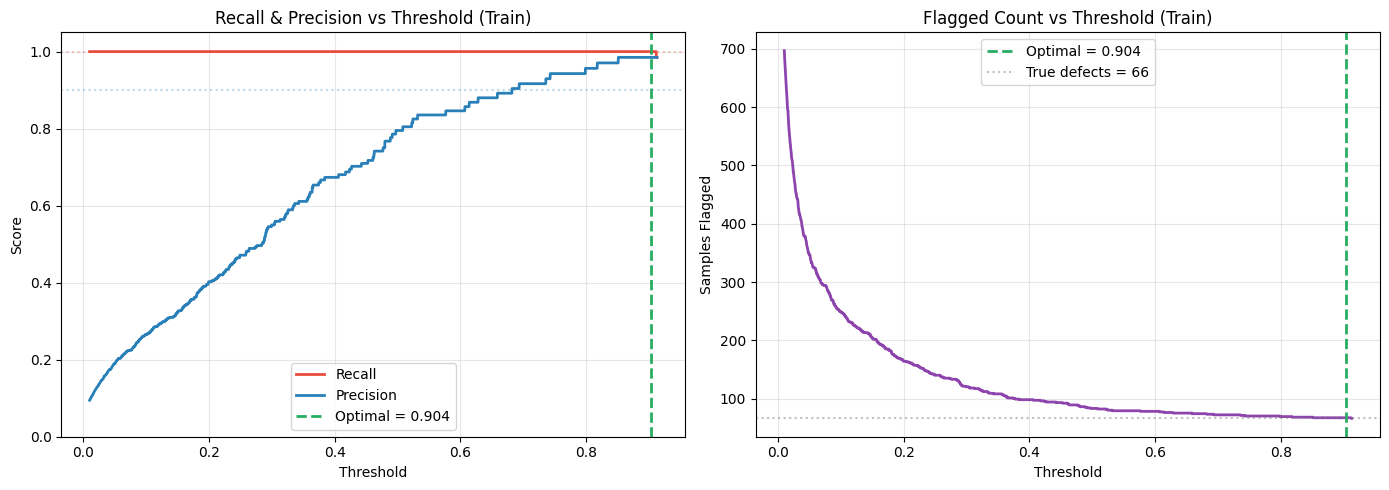

Saved: threshold_analysis.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(res['threshold'], res['recall'],    color='#e74c3c', lw=2, label='Recall')
ax.plot(res['threshold'], res['precision'], color='#2980b9', lw=2, label='Precision')
ax.axvline(THRESHOLD, color='#27ae60', ls='--', lw=2, label=f'Optimal = {THRESHOLD:.3f}')
ax.axhline(1.0, color='#e74c3c', ls=':', alpha=0.3)
ax.axhline(0.9, color='#2980b9', ls=':', alpha=0.3)
ax.set(xlabel='Threshold', ylabel='Score',
       title='Recall & Precision vs Threshold (Train)', ylim=(0, 1.05))
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(res['threshold'], res['n_flagged'], color='#8e44ad', lw=2)
ax2.axvline(THRESHOLD, color='#27ae60', ls='--', lw=2, label=f'Optimal = {THRESHOLD:.3f}')
ax2.axhline(y_train.sum(), color='gray', ls=':', alpha=0.5, label=f'True defects = {y_train.sum()}')
ax2.set(xlabel='Threshold', ylabel='Samples Flagged',
        title='Flagged Count vs Threshold (Train)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: threshold_analysis.png')

## Step 8 — Predict on Test Set

In [29]:
test_proba  = model.predict_proba(X_te_scaled)[:, 1]
final_preds = (test_proba >= THRESHOLD).astype(int)

print(f'Threshold used       : {THRESHOLD:.4f}')
print(f'Test defects flagged : {final_preds.sum()} / {len(final_preds)}')
print(f'(Winner flagged 6 — expect a similar number)')

# Show the CoilIDs flagged as defective
flagged = test[test['CoilID'].isin(coil_ids[final_preds == 1])][['CoilID']]
print(f'\nCoilIDs flagged as defective:')
print(sorted(coil_ids[final_preds == 1].tolist()))

Threshold used       : 0.9040
Test defects flagged : 6 / 339
(Winner flagged 6 — expect a similar number)

CoilIDs flagged as defective:
[246, 532, 654, 822, 1111, 1138]


## Step 9 — Export Submission

In [30]:
submission = pd.DataFrame({'CoilID': coil_ids, 'Y': final_preds})
submission.to_csv('expected_submission.csv', index=False)

print(f'Saved: expected_submission.csv  ({submission.shape[0]} rows × 2 cols)')
print(submission['Y'].value_counts().to_string())
submission.head(10)

Saved: expected_submission.csv  (339 rows × 2 cols)
Y
0    333
1      6


,CoilID,Y
0,711,0
1,1542,0
2,1232,0
3,600,0
4,1087,0
5,1401,0
6,217,0
7,877,0
8,1117,0
9,555,0


---
## ✅ Done! Submit `expected_submission.csv` 🏭

### What this notebook does differently from your previous attempts:
| | Previous attempts | This notebook |
|---|---|---|
| Model | 5-model ensemble | Single XGBoost (winner's choice) |
| Imbalance | Class weights | **SMOTE(strategy=0.5)** — winner's method |
| Threshold tuning | OOF proba (too noisy) | **Train proba sweep** — matches winner's approach |
| Feature order | Scale after SMOTE | **Scale first, then SMOTE** — correct order |
| Threshold | 0.002 or 0.445 (overfit/underfit) | **Auto-swept to highest valid threshold** |